# Iris Flower Classification (Weekend ML Project)

## Goal
Build a supervised machine learning model that predicts the species of an iris flower
(Setosa, Versicolor, Virginica) based on four measurements:

- Sepal length
- Sepal width
- Petal length
- Petal width

## What this notebook covers
1. Load and understand the dataset
2. Basic data validation ("cleaning checks")
3. Exploratory Data Analysis (EDA)
4. Train/test split
5. Feature scaling (standardization)
6. Train 2 classification models (Logistic Regression & KNN)
7. Evaluate performance (accuracy, confusion matrix, classification report)
8. Interpret results and compare models

In [2]:
# -----------------------------
# Imports (libraries we need)
# -----------------------------
import numpy as np                      # Numerical operations and arrays
import pandas as pd                     # DataFrame operations (tables)
import matplotlib.pyplot as plt         # Plotting library (basic graphs)

from sklearn.datasets import load_iris  # Built-in Iris dataset from scikit-learn
from sklearn.model_selection import train_test_split  # Split dataset into train/test
from sklearn.preprocessing import StandardScaler      # Standardize features
from sklearn.linear_model import LogisticRegression   # Classification model #1
from sklearn.neighbors import KNeighborsClassifier    # Classification model #2
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Evaluation metrics

# -----------------------------
# Reproducibility
# -----------------------------
# Setting a seed ensures that randomized operations (like train/test split)
# produce the same output each time you run the notebook.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [5]:
# -----------------------------
# Load Iris dataset
# -----------------------------
# load_iris() returns a "Bunch" object (dictionary-like) containing:
# - data: feature measurements (numpy array)
# - target: numeric labels (0,1,2)
# - target_names: label names (setosa, versicolor, virginica)
# - feature_names: measurement names
iris = load_iris()

# -----------------------------
# Create a DataFrame for easier exploration
# -----------------------------
X = pd.DataFrame(iris.data, columns=iris.feature_names)  # Features (4 columns)
y = pd.Series(iris.target, name="species_id")            # Target labels (0/1/2)

# Add a human-readable species label column (optional but helpful for EDA)
species_label = pd.Series(iris.target_names[iris.target], name="species_label")

# Combine into one DataFrame for inspection
df = pd.concat([X, y, species_label], axis=1)

# Display the first few rows
df.tail(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species_label
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


In [6]:
# -----------------------------
# Basic shape check
# -----------------------------
# Iris dataset has 150 rows and 4 feature columns (plus our added label columns).
print("Dataset shape:", df.shape)

# -----------------------------
# Summary: column names and types
# -----------------------------
df.info()

# -----------------------------
# Summary statistics for numerical columns
# -----------------------------
# This gives mean, std, min, max, quartiles for each feature.
df.describe()

Dataset shape: (150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species_id         150 non-null    int64  
 5   species_label      150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [7]:
# "Cleaning" Checks (Missing Values, Duplicates, Label Balance)
# -----------------------------
# Check for missing values
# -----------------------------
# For many ML models, missing values must be handled (imputed/dropped).
# Iris dataset is clean, but we verify anyway.
print("Missing values per column:\n", df.isnull().sum())

# -----------------------------
# Check for duplicate rows
# -----------------------------
# Duplicates can sometimes bias training; we check how many duplicates exist.
duplicate_count = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicate_count)

# -----------------------------
# Label distribution (class balance)
# -----------------------------
# A balanced dataset means each class has a similar number of samples.
# If a dataset is imbalanced, accuracy alone can be misleading.
print("\nClass distribution (numeric labels):\n", df["species_id"].value_counts())
print("\nClass distribution (string labels):\n", df["species_label"].value_counts())

Missing values per column:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species_id           0
species_label        0
dtype: int64

Number of duplicate rows: 1

Class distribution (numeric labels):
 species_id
0    50
1    50
2    50
Name: count, dtype: int64

Class distribution (string labels):
 species_label
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


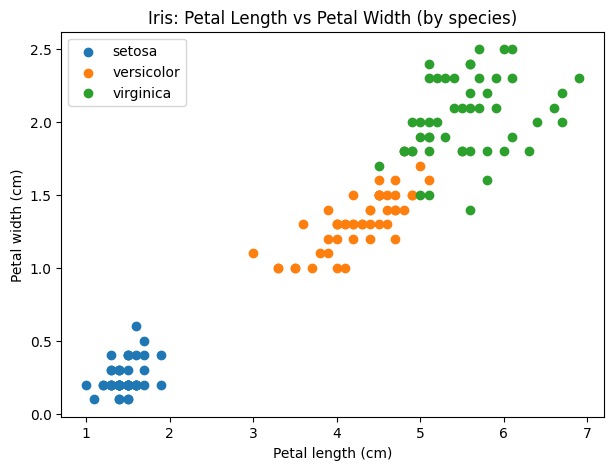

In [8]:
#
# -----------------------------
# Simple EDA: scatter plots
# -----------------------------
# Iris is famous because petal measurements separate species well.
# We'll plot petal length vs petal width (often shows clear separation).

plt.figure(figsize=(7, 5))

# Plot each class separately so we can visually see clusters.
for species_id, species_name in enumerate(iris.target_names):
    subset = df[df["species_id"] == species_id]
    plt.scatter(
        subset["petal length (cm)"],
        subset["petal width (cm)"],
        label=species_name
    )

plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Iris: Petal Length vs Petal Width (by species)")
plt.legend()
plt.show()

In [9]:
# Prepare ML Data: Features (X) and Target (y)
# -----------------------------
# ML-ready feature matrix and target vector
# -----------------------------
# X = only the numeric feature columns
# y = the species labels (0,1,2) for classification
X = df[iris.feature_names].copy()
y = df["species_id"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [10]:
# -----------------------------
# Train/Test Split
# -----------------------------
# Why split?
# - Train set: used to fit/learn model parameters
# - Test set: held out for unbiased evaluation

# stratify=y ensures each class proportion is maintained in both train and test sets
# which is important especially when classes may be imbalanced (not the case here, but best practice).
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,         # 20% test set, 80% training set
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 120
Test size: 30


In [11]:
# -----------------------------
# Standardization
# -----------------------------
# Some models (like Logistic Regression and KNN) benefit from features being on similar scales.
# StandardScaler transforms each feature to have:
# - mean = 0
# - standard deviation = 1

scaler = StandardScaler()

# IMPORTANT:
# Fit scaler ONLY on training data to avoid "data leakage" from test data.
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to test data using the fitted scaler.
X_test_scaled = scaler.transform(X_test)

print("Scaled training set shape:", X_train_scaled.shape)
print("Scaled test set shape:", X_test_scaled.shape)

Scaled training set shape: (120, 4)
Scaled test set shape: (30, 4)


In [12]:
# -----------------------------
# Model 1: Logistic Regression
# -----------------------------
# Logistic Regression is a strong baseline for multi-class classification.
# It learns linear decision boundaries.

log_reg = LogisticRegression(
    max_iter=200,          # Increase iterations to ensure convergence
    random_state=RANDOM_STATE
)

# Train the model on scaled training data
log_reg.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_lr = log_reg.predict(X_test_scaled)

# Evaluate accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.9333333333333333


In [13]:
# -----------------------------
# Model 2: K-Nearest Neighbors (KNN)
# -----------------------------
# KNN predicts a label based on the majority class among the K nearest points.
# Scaling is important because KNN uses distance calculations.

knn = KNeighborsClassifier(
    n_neighbors=5  # Common starting choice; can tune later
)

# Train the model
knn.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_knn = knn.predict(X_test_scaled)

# Evaluate accuracy
acc_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", acc_knn)


KNN Accuracy: 0.9333333333333333


In [14]:
# -----------------------------
# Confusion Matrix + Classification Report
# -----------------------------
# Confusion matrix shows how many samples were correctly/incorrectly classified by class.
# Classification report includes precision, recall, f1-score per class.

def evaluate_model(name, y_true, y_pred):
    print(f"\n==================== {name} ====================")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=iris.target_names))

# Evaluate both models
evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("KNN", y_test, y_pred_knn)


==================== Logistic Regression ====================
Accuracy: 0.9333333333333333

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


==================== KNN ====================
Accuracy: 0.9333333333333333

Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg   

In [15]:
# -----------------------------
# Compare model performance
# -----------------------------
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN (k=5)"],
    "Test Accuracy": [acc_lr, acc_knn]
}).sort_values(by="Test Accuracy", ascending=False)

results

,Model,Test Accuracy
0,Logistic Regression,0.933333
1,KNN (k=5),0.933333


In [16]:
# -----------------------------
# Interpret feature importance (for Logistic Regression)
# -----------------------------
# For multi-class logistic regression, coefficients exist per class.
# We'll display them in a DataFrame for interpretation.

coef_df = pd.DataFrame(
    log_reg.coef_,
    columns=iris.feature_names,
    index=iris.target_names
)

coef_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,-1.088945,1.024208,-1.799056,-1.686228
versicolor,0.536337,-0.360487,-0.204074,-0.807957
virginica,0.552608,-0.663721,2.003130,2.494185


In [19]:
# -----------------------------
# Bonus: Predict a single example
# -----------------------------
# Here is a made-up flower measurement:
# [sepal length, sepal width, petal length, petal width]
# new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])
new_flower = np.array([[8.2, 5.67, 4.1, 3.0]])

# Scale it using the same scaler fit on training data
new_flower_scaled = scaler.transform(new_flower)

# Predict using both models
pred_lr = log_reg.predict(new_flower_scaled)[0]
pred_knn = knn.predict(new_flower_scaled)[0]

print("Logistic Regression predicts:", iris.target_names[pred_lr])
print("KNN predicts:", iris.target_names[pred_knn])

Logistic Regression predicts: virginica
KNN predicts: virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
